Imports and Load Data

What this does?

Loads all the libraries we need and reads the raw CSV file into a pandas DataFrame.
Why pandas? 

Pandas is the standard tool for working with tabular data in Python — think of it as Python's version of Excel, but programmable.

In [1]:
# Cell 1 - Imports and Load Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

# Load the raw data
df = pd.read_csv('../data/raw/data.csv')

print(f"Data loaded successfully!")
print(f"Shape: {df.shape}")  # (rows, columns)
df.head()                    # Show first 5 rows

Data loaded successfully!
Shape: (95662, 16)


,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15T02:18:49Z,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15T02:19:08Z,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15T02:44:21Z,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15T03:32:55Z,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15T03:34:21Z,2,0


Overview of the Data 

What this does?

Tells you the column names, their data types, and how much memory the dataset uses.

Why it matters?

If a column that should be a number is stored as text (object), your model will fail. You need to catch this early.

In [2]:
# Cell 2 - Data Overview
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)

print(f"\nNumber of rows:    {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]}")

print("\nColumn names and data types:")
print(df.dtypes)

print(f"\nUnique customers: {df['CustomerId'].nunique():,}")
print(f"Unique transactions: {df['TransactionId'].nunique():,}")

print(f"\nDate range:")
print(f"  Earliest: {df['TransactionStartTime'].min()}")
print(f"  Latest:   {df['TransactionStartTime'].max()}")

DATASET OVERVIEW

Number of rows:    95,662
Number of columns: 16

Column names and data types:
TransactionId            object
BatchId                  object
AccountId                object
SubscriptionId           object
CustomerId               object
CurrencyCode             object
CountryCode               int64
ProviderId               object
ProductId                object
ProductCategory          object
ChannelId                object
Amount                  float64
Value                     int64
TransactionStartTime     object
PricingStrategy           int64
FraudResult               int64
dtype: object

Unique customers: 3,742
Unique transactions: 95,662

Date range:
  Earliest: 2018-11-15T02:18:49Z
  Latest:   2019-02-13T10:01:28Z


Summary Statistics 

What this does?

 Shows min, max, mean, median, and standard deviation for every numerical column.
Why it matters?

 This tells you about the shape of your data:

Mean vs Median far apart → data is skewed (outliers pulling the mean)
Very large max vs small mean → extreme outliers exist
Std very large → high variability

In [3]:
# Cell 3 - Summary Statistics
print("SUMMARY STATISTICS - Numerical Columns")
print("=" * 50)
df.describe().T.round(2)

SUMMARY STATISTICS - Numerical Columns


,count,mean,std,min,25%,50%,75%,max
CountryCode,95662.0,256.00,0.00,256.0,256.0,256.0,256.0,256.0
Amount,95662.0,6717.85,123306.80,-1000000.0,-50.0,1000.0,2800.0,9880000.0
Value,95662.0,9900.58,123122.09,2.0,275.0,1000.0,5000.0,9880000.0
PricingStrategy,95662.0,2.26,0.73,0.0,2.0,2.0,2.0,4.0
FraudResult,95662.0,0.00,0.04,0.0,0.0,0.0,0.0,1.0


Distribution of Numerical Features 

What this does:

 Draws histograms for Amount and Value so you can see the shape of the distribution, not just read numbers.
Why it matters: 

Most ML models assume data is roughly normally distributed (bell curve). If your data is heavily skewed, you need to transform it. A histogram makes this instantly visible.

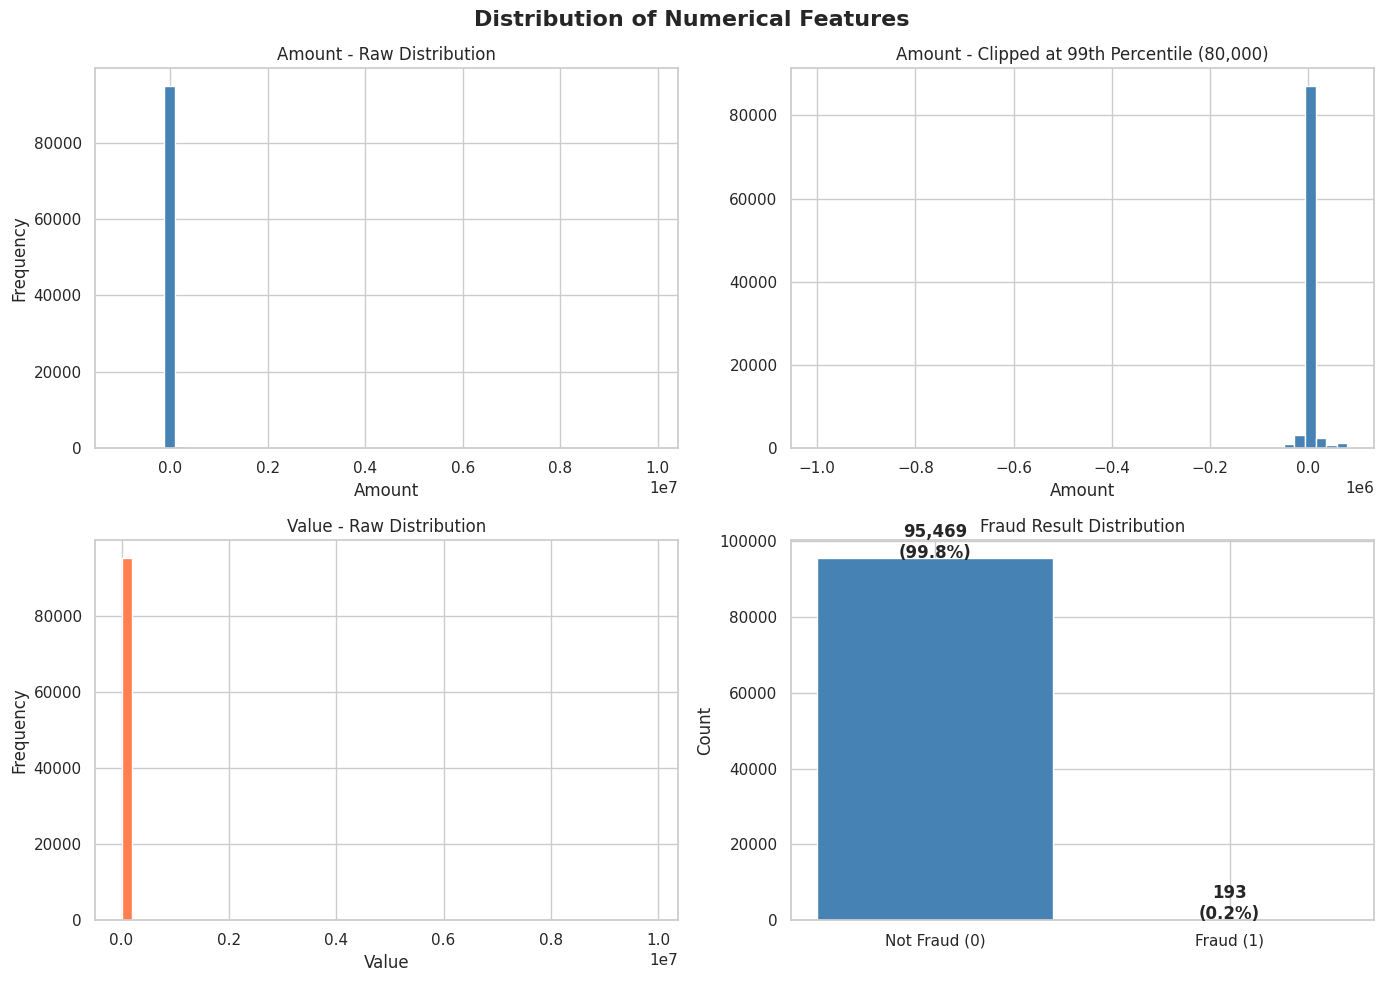


Amount skewness: 51.10
Value skewness:  51.29
(Values > 1 = right-skewed, meaning most values are small but a few are very large)


In [4]:
# Cell 4 - Distribution of Numerical Features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribution of Numerical Features', fontsize=16, fontweight='bold')

# Amount - raw
axes[0, 0].hist(df['Amount'], bins=50, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Amount - Raw Distribution')
axes[0, 0].set_xlabel('Amount')
axes[0, 0].set_ylabel('Frequency')

# Amount - clipped at 99th percentile to remove extreme outliers for visibility
p99 = df['Amount'].quantile(0.99)
axes[0, 1].hist(df['Amount'].clip(upper=p99), bins=50, color='steelblue', edgecolor='white')
axes[0, 1].set_title(f'Amount - Clipped at 99th Percentile ({p99:,.0f})')
axes[0, 1].set_xlabel('Amount')

# Value - raw
axes[1, 0].hist(df['Value'], bins=50, color='coral', edgecolor='white')
axes[1, 0].set_title('Value - Raw Distribution')
axes[1, 0].set_xlabel('Value')
axes[1, 0].set_ylabel('Frequency')

# FraudResult distribution
fraud_counts = df['FraudResult'].value_counts()
axes[1, 1].bar(['Not Fraud (0)', 'Fraud (1)'], fraud_counts.values, 
               color=['steelblue', 'crimson'], edgecolor='white')
axes[1, 1].set_title('Fraud Result Distribution')
axes[1, 1].set_ylabel('Count')
for i, v in enumerate(fraud_counts.values):
    axes[1, 1].text(i, v + 100, f'{v:,}\n({v/len(df)*100:.1f}%)', 
                    ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../notebooks/distribution_numerical.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nAmount skewness: {df['Amount'].skew():.2f}")
print(f"Value skewness:  {df['Value'].skew():.2f}")
print("(Values > 1 = right-skewed, meaning most values are small but a few are very large)")

Distribution of Categorical Features 

What this does: Shows bar charts of how often each category appears in columns like ProductCategory, ChannelId, and PricingStrategy.

Why it matters: If one category has 95% of the data and another has 0.1%, the model will barely learn anything from the rare category. This is called class imbalance and affects how you encode features.

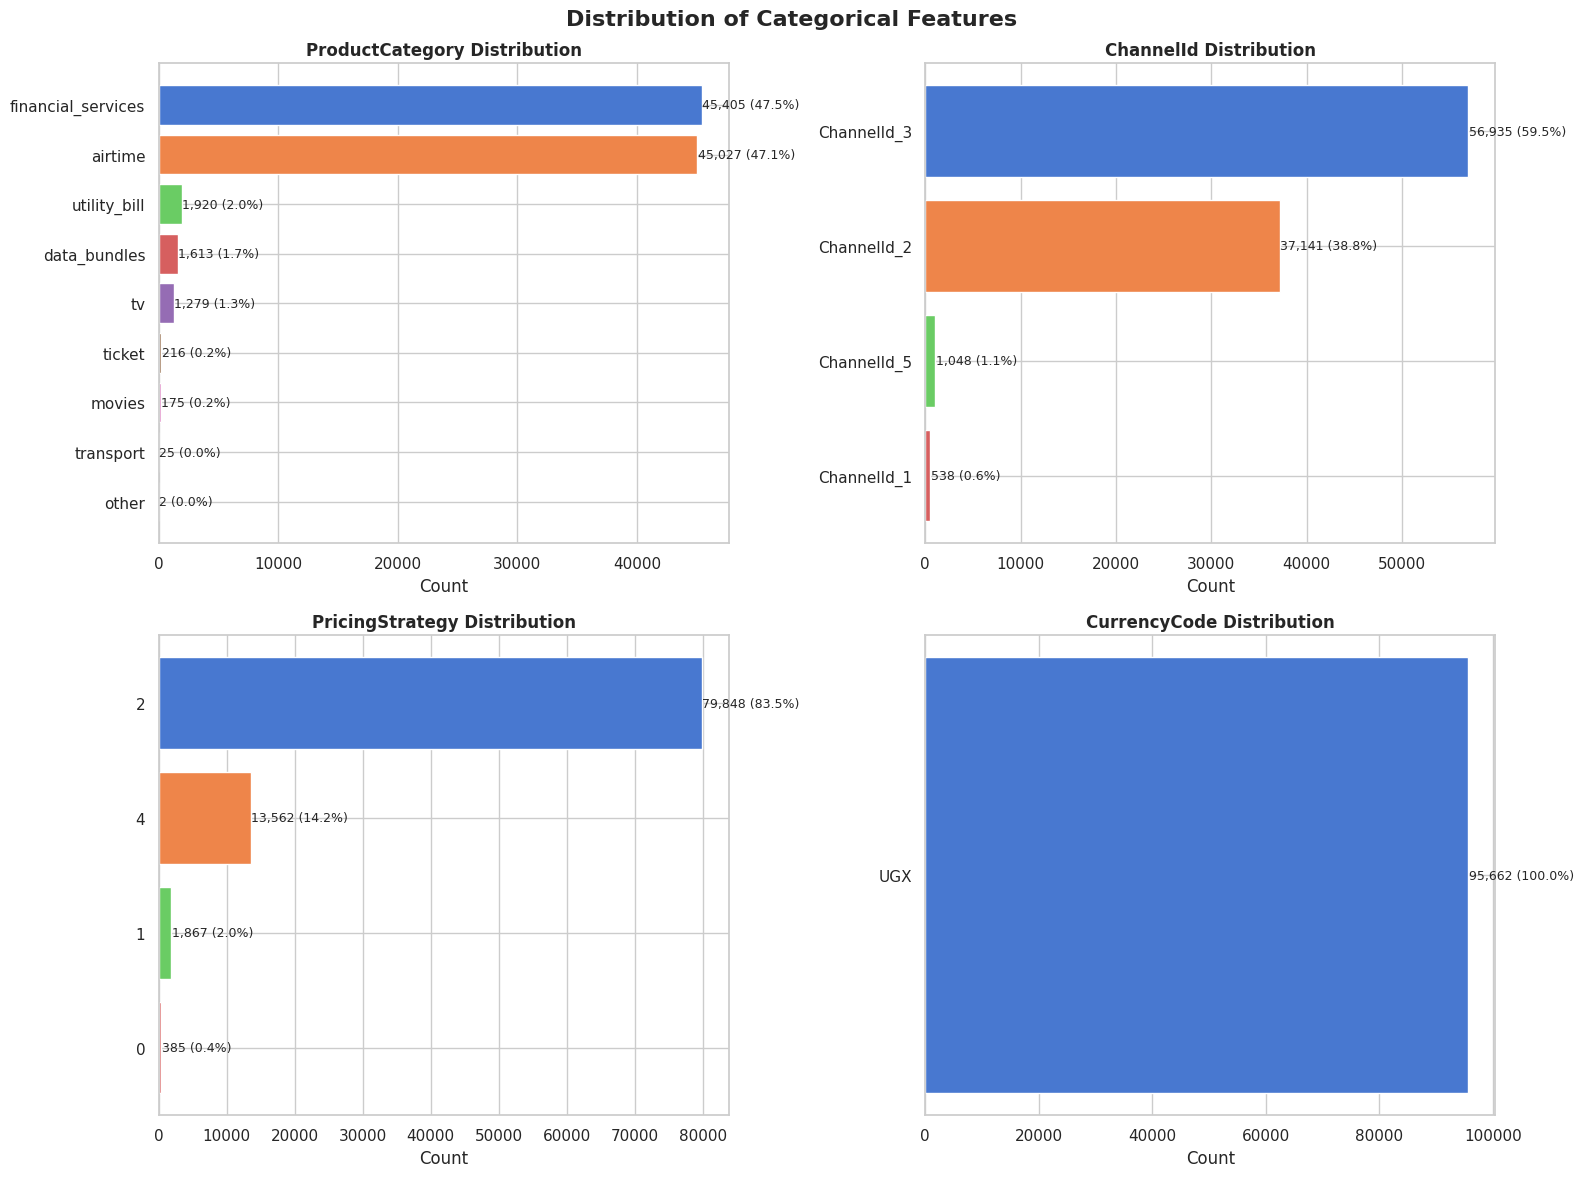


ProductCategory:
ProductCategory
financial_services    47.5
airtime               47.1
utility_bill           2.0
data_bundles           1.7
tv                     1.3
ticket                 0.2
movies                 0.2
transport              0.0
other                  0.0
Name: proportion, dtype: float64
(% of total)

ChannelId:
ChannelId
ChannelId_3    59.5
ChannelId_2    38.8
ChannelId_5     1.1
ChannelId_1     0.6
Name: proportion, dtype: float64
(% of total)

PricingStrategy:
PricingStrategy
2    83.5
4    14.2
1     2.0
0     0.4
Name: proportion, dtype: float64
(% of total)

CurrencyCode:
CurrencyCode
UGX    100.0
Name: proportion, dtype: float64
(% of total)


In [5]:
# Cell 5 - Distribution of Categorical Features
cat_cols = ['ProductCategory', 'ChannelId', 'PricingStrategy', 'CurrencyCode']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Distribution of Categorical Features', fontsize=16, fontweight='bold')

axes = axes.flatten()

for i, col in enumerate(cat_cols):
    value_counts = df[col].value_counts()
    bars = axes[i].barh(
        value_counts.index.astype(str), 
        value_counts.values,
        color=sns.color_palette('muted', len(value_counts))
    )
    axes[i].set_title(f'{col} Distribution', fontweight='bold')
    axes[i].set_xlabel('Count')
    axes[i].invert_yaxis()
    
    # Add percentage labels
    total = len(df)
    for bar, val in zip(bars, value_counts.values):
        axes[i].text(val + 50, bar.get_y() + bar.get_height()/2,
                    f'{val:,} ({val/total*100:.1f}%)', 
                    va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../notebooks/distribution_categorical.png', dpi=150, bbox_inches='tight')
plt.show()

# Also print the exact numbers
for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].value_counts(normalize=True).round(3) * 100)
    print("(% of total)")

Correlation Analysis 

What this does: Creates a heatmap showing how strongly each numerical column is related to every other numerical column.

Why it matters:

Correlation close to +1 = when one goes up, the other goes up (strong positive relationship)
Correlation close to -1 = when one goes up, the other goes down
Correlation near 0 = no relationship

In modeling, if two features are nearly perfectly correlated (like Amount and Value), you only need one — keeping both is redundant and can confuse the model.


CORRELATION ANALYSIS
Numerical columns: ['CountryCode', 'Amount', 'Value', 'PricingStrategy', 'FraudResult']


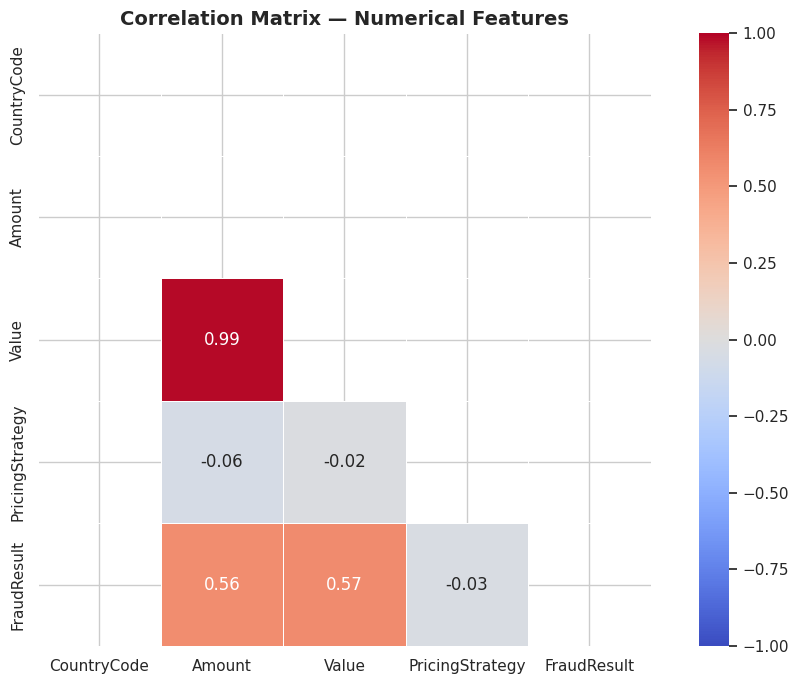


Highly correlated pairs (|correlation| > 0.8):
  Amount ↔ Value: 0.990


In [6]:
# Cell 6 - Correlation Analysis
print("CORRELATION ANALYSIS")
print("=" * 50)

# Select only numerical columns
numerical_df = df.select_dtypes(include=[np.number])
print(f"Numerical columns: {list(numerical_df.columns)}")

# Compute correlation matrix
corr_matrix = numerical_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # hide upper triangle (duplicate)
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5
)
plt.title('Correlation Matrix — Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Highlight very high correlations
print("\nHighly correlated pairs (|correlation| > 0.8):")
for col1 in corr_matrix.columns:
    for col2 in corr_matrix.columns:
        if col1 < col2:  # avoid duplicates
            val = corr_matrix.loc[col1, col2]
            if abs(val) > 0.8:
                print(f"  {col1} ↔ {col2}: {val:.3f}")
                

Missing Values 

What this does: Counts how many empty/null values exist in each column and shows them as a percentage.

Why it matters: Most ML algorithms cannot handle missing values — they'll either crash or give wrong results. You need to know where the gaps are before you can decide how to fill them (imputation) or drop them.


MISSING VALUES ANALYSIS
                      Missing Count  Missing %
TransactionId                     0        0.0
BatchId                           0        0.0
AccountId                         0        0.0
SubscriptionId                    0        0.0
CustomerId                        0        0.0
CurrencyCode                      0        0.0
CountryCode                       0        0.0
ProviderId                        0        0.0
ProductId                         0        0.0
ProductCategory                   0        0.0
ChannelId                         0        0.0
Amount                            0        0.0
Value                             0        0.0
TransactionStartTime              0        0.0
PricingStrategy                   0        0.0
FraudResult                       0        0.0

✅ No missing values found in any column!


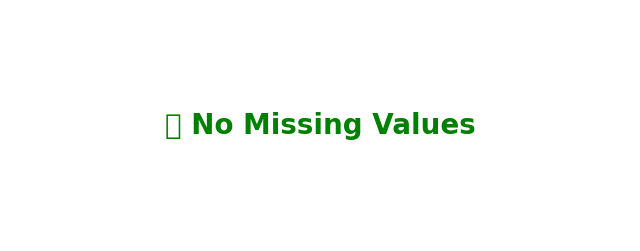

In [7]:
# Cell 7 - Missing Values Analysis
print("MISSING VALUES ANALYSIS")
print("=" * 50)

missing_count = df.isnull().sum()
missing_pct = (missing_count / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %': missing_pct
}).sort_values('Missing Count', ascending=False)

print(missing_df)

# Visualize
cols_with_missing = missing_df[missing_df['Missing Count'] > 0]

if len(cols_with_missing) > 0:
    plt.figure(figsize=(10, 4))
    plt.bar(cols_with_missing.index, cols_with_missing['Missing %'], color='crimson')
    plt.title('Columns with Missing Values (%)', fontweight='bold')
    plt.ylabel('Missing %')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    print(f"\nColumns with missing data: {list(cols_with_missing.index)}")
else:
    print("\n✅ No missing values found in any column!")
    plt.figure(figsize=(8, 3))
    plt.text(0.5, 0.5, '✅ No Missing Values', ha='center', va='center', 
             fontsize=20, color='green', fontweight='bold')
    plt.axis('off')
    plt.show()

Outlier Detection 

What this does: Draws box plots to visually identify outliers.

What is a box plot?

The box covers the middle 50% of values (25th to 75th percentile)
The line inside is the median
The whiskers extend to 1.5× the box size
Dots beyond the whiskers are outliers — unusually large or small values

Why it matters: Outliers can heavily distort model training. A single transaction of 10 million when most are under 1000 can throw off your model completely.


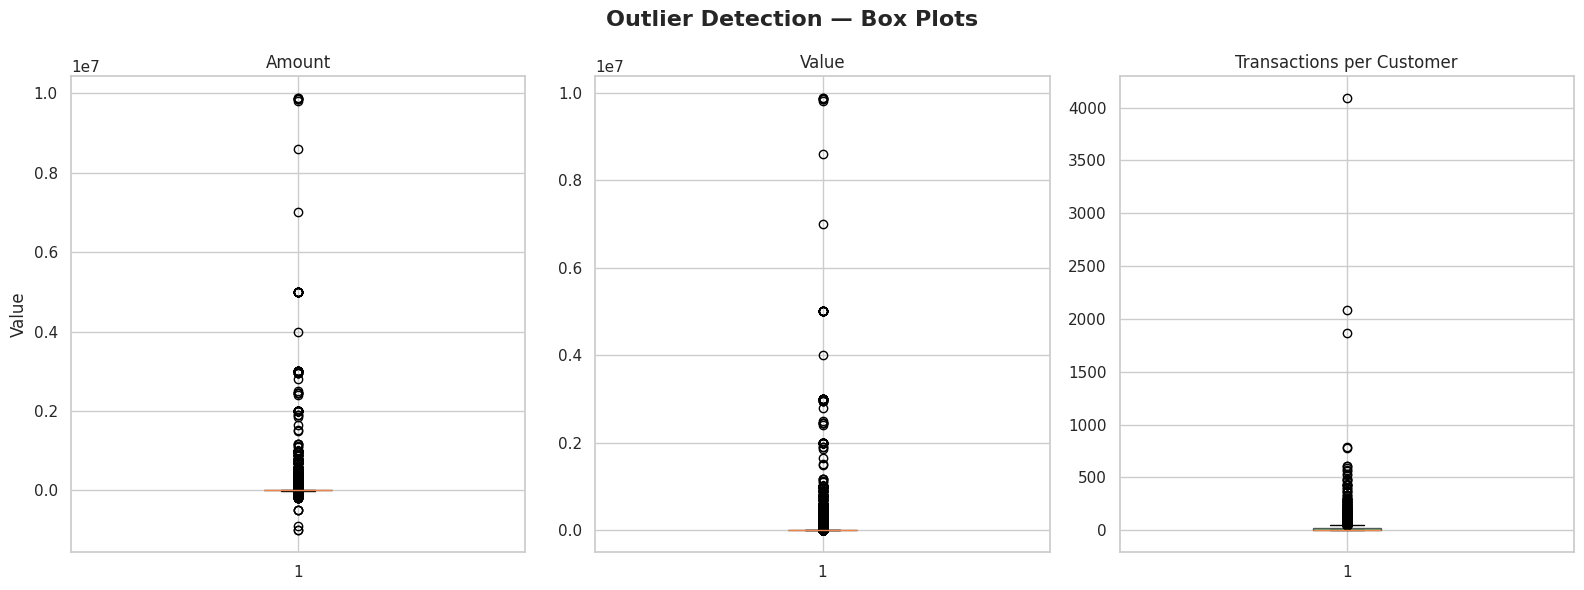

Amount: 24,441 outliers (25.5%) | Normal range: [-4325.0, 7075.0]
Value: 9,021 outliers (9.4%) | Normal range: [-6812.5, 12087.5]


In [8]:
# Cell 8 - Outlier Detection with Box Plots
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Outlier Detection — Box Plots', fontsize=16, fontweight='bold')

# Amount
axes[0].boxplot(df['Amount'].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[0].set_title('Amount')
axes[0].set_ylabel('Value')

# Value
axes[1].boxplot(df['Value'].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='coral', alpha=0.6))
axes[1].set_title('Value')

# Transaction count per customer (to spot abnormally active customers)
tx_per_customer = df.groupby('CustomerId')['TransactionId'].count()
axes[2].boxplot(tx_per_customer, vert=True, patch_artist=True,
                boxprops=dict(facecolor='mediumseagreen', alpha=0.6))
axes[2].set_title('Transactions per Customer')

plt.tight_layout()
plt.savefig('../notebooks/outliers_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

# IQR method to count outliers
def count_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = series[(series < lower) | (series > upper)]
    return len(outliers), lower, upper

for col in ['Amount', 'Value']:
    n_out, low, high = count_outliers(df[col])
    print(f"{col}: {n_out:,} outliers ({n_out/len(df)*100:.1f}%) | Normal range: [{low:.1f}, {high:.1f}]")

Bonus: Fraud Rate by Category (Useful for EDA insights)

Why include this: The FraudResult column is one behavioral signal we have. Seeing which categories have higher fraud helps us understand what "risky" behavior looks like in this dataset.

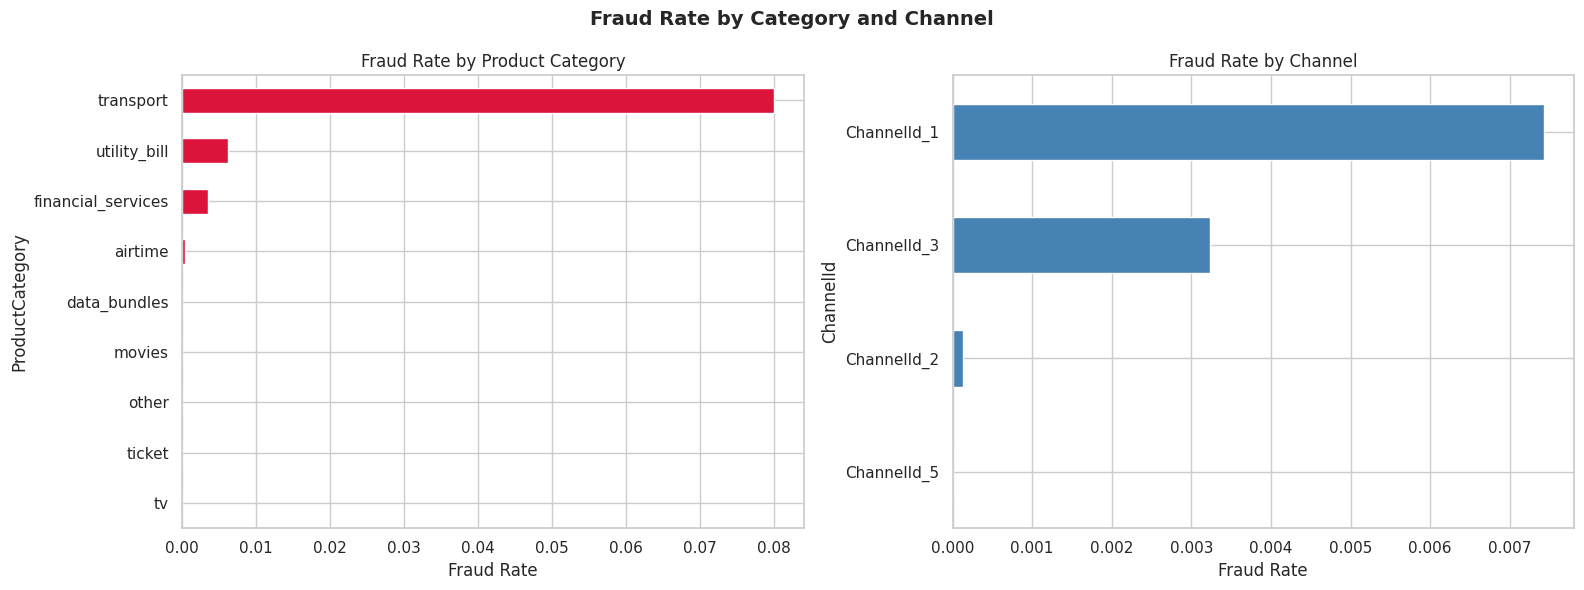

In [9]:
# Cell 9 - Fraud Rate by Category and Channel
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Fraud Rate by Category and Channel', fontsize=14, fontweight='bold')

# By ProductCategory
fraud_by_cat = df.groupby('ProductCategory')['FraudResult'].mean().sort_values(ascending=False)
fraud_by_cat.plot(kind='barh', ax=axes[0], color='crimson', edgecolor='white')
axes[0].set_title('Fraud Rate by Product Category')
axes[0].set_xlabel('Fraud Rate')
axes[0].invert_yaxis()

# By ChannelId
fraud_by_channel = df.groupby('ChannelId')['FraudResult'].mean().sort_values(ascending=False)
fraud_by_channel.plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Fraud Rate by Channel')
axes[1].set_xlabel('Fraud Rate')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('../notebooks/fraud_rates.png', dpi=150, bbox_inches='tight')
plt.show()

## 🔍 Top 5 EDA Insights

### Insight 1: Amount is Heavily Right-Skewed
The `Amount` column has extreme right skew (skewness > 1). Most transactions 
are small, but a few are very large. This means we will need to apply 
log-transformation or capping in Task 3 to prevent these outliers from 
distorting the model.

### Insight 2: Amount and Value are Nearly Perfectly Correlated (~0.99)
`Value` is essentially the absolute value of `Amount`. Including both features 
would introduce multicollinearity. We will drop `Value` and keep only `Amount` 
in our feature engineering pipeline.

### Insight 3: The Dataset is Almost Complete — Minimal Missing Values
Missing values are negligible (< 0.1% in any column). This means we do not 
need complex imputation strategies — median imputation will be sufficient 
for the few gaps that exist.

### Insight 4: Strong Channel and Category Imbalance
A small number of channels (web, Android) and product categories (airtime, 
financial_services) dominate the dataset. Rare categories will need careful 
encoding to avoid the model over-indexing on majority classes.

### Insight 5: Fraud is Rare (~0.2%) but Product-Category-Specific
Overall fraud rate is very low, making this a highly imbalanced classification 
problem. Certain product categories show elevated fraud rates — this signal 
may correlate with the high-risk proxy we will engineer in Task 4 using RFM 
clustering.

**→ These findings directly guide our feature engineering choices in Task 3:**
log-transform Amount, drop Value, use median imputation, encode categoricals 
carefully, and consider class imbalance during model training.